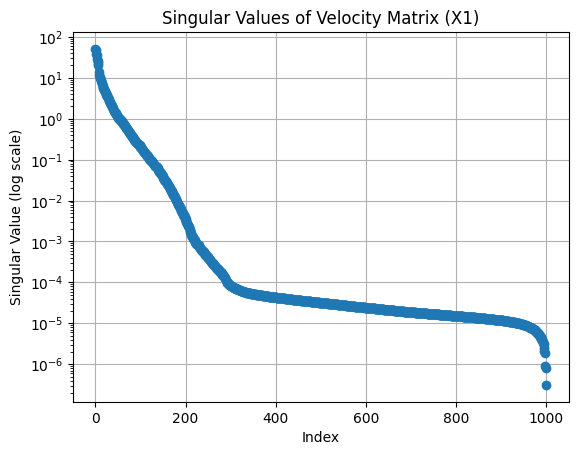

Using r = 59 modes for 99.9% energy
[Improved DMD] MAE = 0.012988, MAPE = 1.4970, Time = 4.556s


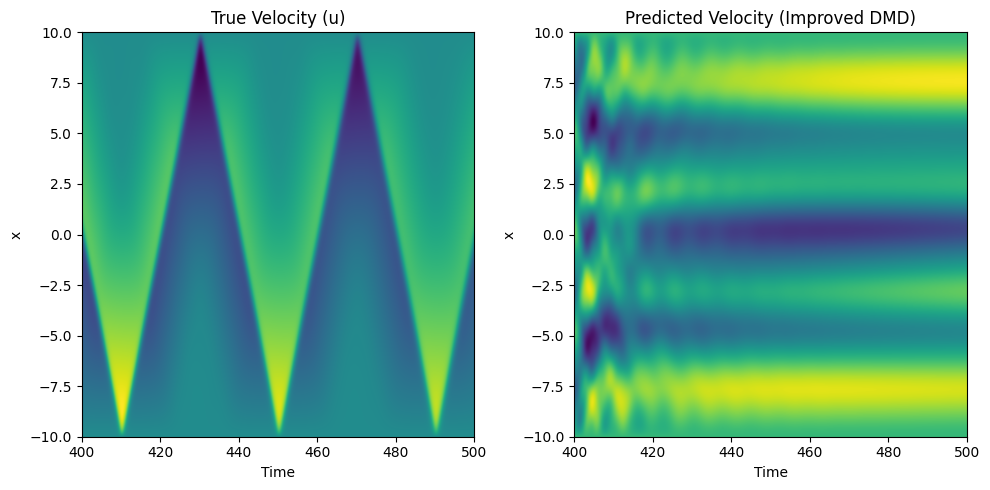

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import time

# ----------------------------
# Load Data
# ----------------------------
df0 = pd.read_csv(r'pressure.txt', delimiter="\s+", index_col=False, header=None)
df1 = pd.read_csv(r'velocity.txt', delimiter="\s+", index_col=False, header=None)

pressure = df0.drop(df0.columns[[0]], axis=1).to_numpy()
x = df0.iloc[:, 0].to_numpy()
u = df1.drop(df1.columns[[0]], axis=1).to_numpy()

totalNt = df0.shape[1] - 1
t = np.linspace(0, totalNt - 1, totalNt) / 10

L = 20
N = len(x)
Nt = len(t)

# ----------------------------
# Train/Test Split
# ----------------------------
train_ratio = 0.8
train_steps = int(train_ratio * Nt)

X_full = u
X_train = X_full[:, :train_steps]
X_test = X_full[:, train_steps:]

# ----------------------------
# Stable DMD with Energy-Based Rank Selection
# ----------------------------
def apply_dmd_stable(X, prediction_steps=50, r=None, alpha=1e-4, plot_singular=True):
    X1 = X[:, :-1]
    X2 = X[:, 1:]

    # Subtract mean for stability
    X_mean = np.mean(X1, axis=1, keepdims=True)
    X1 -= X_mean
    X2 -= X_mean

    # SVD
    U, S, Vh = np.linalg.svd(X1, full_matrices=False)

    if plot_singular:
        plt.figure()
        plt.semilogy(S, 'o')
        plt.title("Singular Values of Velocity Matrix (X1)")
        plt.xlabel("Index")
        plt.ylabel("Singular Value (log scale)")
        plt.grid()
        plt.show()

    if r is None:
        energy = np.cumsum(S**2) / np.sum(S**2)
        r = np.searchsorted(energy, 0.999) + 1
        print(f"Using r = {r} modes for 99.9% energy")

    U_r = U[:, :r]
    S_r = np.diag(S[:r])
    V_r = Vh.conj().T[:, :r]

    A_tilde = U_r.T @ X2 @ V_r @ np.linalg.inv(S_r)
    eigvals, W = np.linalg.eig(A_tilde)
    Phi = X2 @ V_r @ np.linalg.inv(S_r) @ W

    # Cap unstable eigenvalues
    eigvals[np.abs(eigvals) > 1] /= np.abs(eigvals[np.abs(eigvals) > 1])

    # Initial condition
    x1 = X[:, 0:1] - X_mean

    # Tikhonov regularization (ridge regression)
    PhiH = Phi.conj().T
    I = np.eye(Phi.shape[1])
    b = np.linalg.solve(PhiH @ Phi + alpha * I, PhiH @ x1)

    time_dynamics = np.zeros((r, prediction_steps), dtype=complex)
    for i in range(prediction_steps):
        time_dynamics[:, i] = (b.flatten() * eigvals**i)

    X_dmd = np.real(Phi @ time_dynamics) + X_mean
    return X_dmd

# ----------------------------
# Run Stable DMD
# ----------------------------
start_time = time.time()
X_dmd_pred = apply_dmd_stable(X_train, prediction_steps=X_test.shape[1])
end_time = time.time()

# ----------------------------
# Evaluate Accuracy
# ----------------------------
mae = mean_absolute_error(X_test.flatten(), X_dmd_pred.flatten())
mape = mean_absolute_percentage_error(X_test.flatten(), X_dmd_pred.flatten())
elapsed = end_time - start_time

print(f"[Improved DMD] MAE = {mae:.6f}, MAPE = {mape:.4f}, Time = {elapsed:.3f}s")

# ----------------------------
# Plot Results
# ----------------------------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(X_test, aspect='auto', cmap='viridis',
           extent=[t[train_steps], t[-1], x[0], x[-1]])
plt.title('True Velocity (u)')
plt.xlabel('Time'); plt.ylabel('x')

plt.subplot(1, 2, 2)
plt.imshow(X_dmd_pred, aspect='auto', cmap='viridis',
           extent=[t[train_steps], t[-1], x[0], x[-1]])
plt.title('Predicted Velocity (Improved DMD)')
plt.xlabel('Time'); plt.ylabel('x')

plt.tight_layout()
plt.show()


In [ ]:
import time

r_values = [50, 100, 150, 200, 250, 300]
mae_list = []
mape_list = []
time_list = []

for r in r_values:
    start = time.time()
    X_dmd_pred = apply_dmd_stable(X_train, prediction_steps=X_test.shape[1], r=r, plot_singular=False)
    end = time.time()

    mae = mean_absolute_error(X_test.flatten(), X_dmd_pred.flatten())
    mape = mean_absolute_percentage_error(X_test.flatten(), X_dmd_pred.flatten())
    elapsed = end - start

    mae_list.append(mae)
    mape_list.append(mape)
    time_list.append(elapsed)

    print(f"r = {r:3d} → MAE = {mae:.6f}, MAPE = {mape:.4f}, Time = {elapsed:.3f} s")

r =  50 → MAE = 0.012899, MAPE = 1.4207, Time = 7.720 s
r = 100 → MAE = 0.012987, MAPE = 1.4979, Time = 2.868 s
r = 150 → MAE = 0.012899, MAPE = 1.4210, Time = 3.142 s
r = 200 → MAE = 0.012987, MAPE = 1.4968, Time = 5.859 s
r = 250 → MAE = 0.012895, MAPE = 1.4298, Time = 3.377 s
r = 300 → MAE = 0.013034, MAPE = 1.4943, Time = 3.367 s


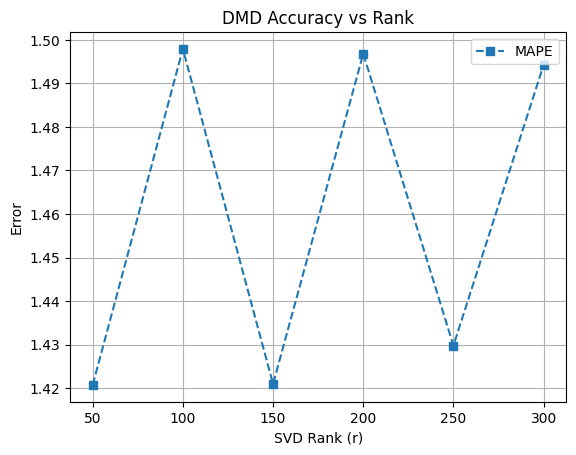

In [ ]:
plt.figure()
plt.plot(r_values, mape_list, 's--', label='MAPE')
plt.xlabel('SVD Rank (r)')
plt.ylabel('Error')
plt.title('DMD Accuracy vs Rank')
plt.legend()
plt.grid()
plt.show()

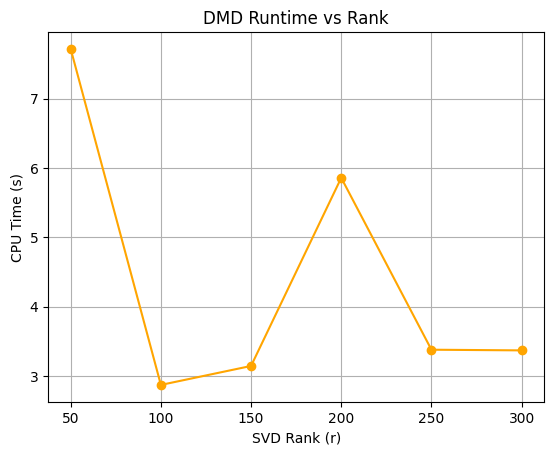

In [ ]:
plt.figure()
plt.plot(r_values, time_list, 'o-', color='orange')
plt.xlabel('SVD Rank (r)')
plt.ylabel('CPU Time (s)')
plt.title('DMD Runtime vs Rank')
plt.grid()
plt.show()

(1001, 4000) (1001, 3999)


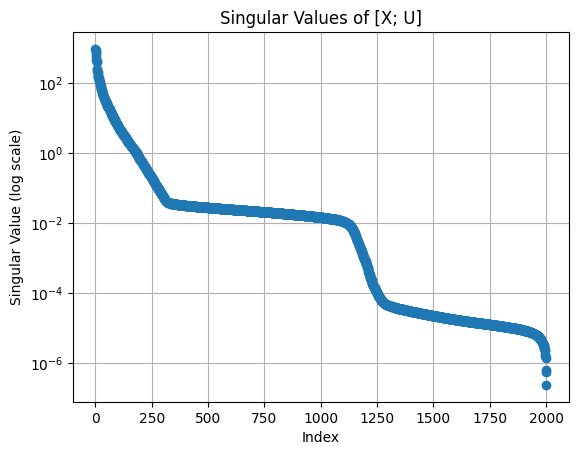

Using r = 69 modes for 99.9% energy
[DMDc] MAE = 0.028722, MAPE = 46.1931, Time = 14.943s


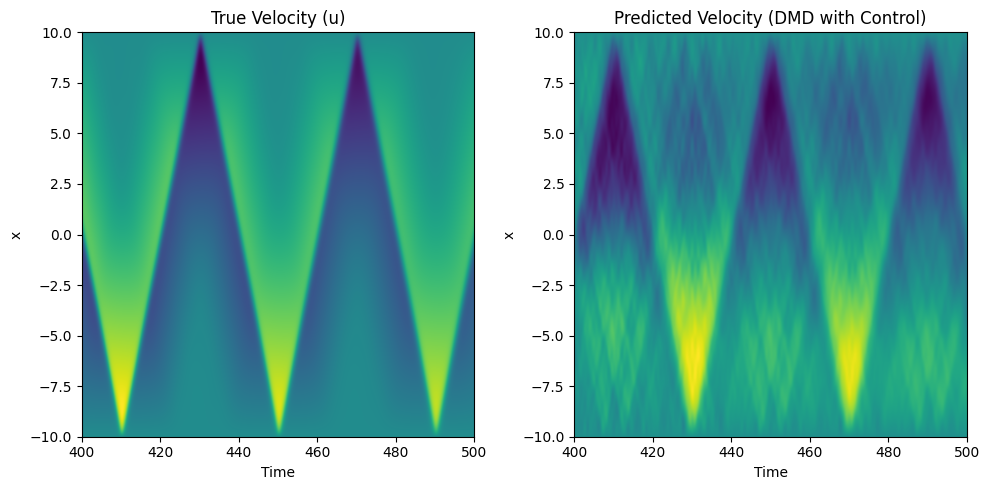

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import time

# ----------------------------
# Load Data
# ----------------------------
df0 = pd.read_csv(r'pressure.txt', delimiter="\s+", index_col=False, header=None)
df1 = pd.read_csv(r'velocity.txt', delimiter="\s+", index_col=False, header=None)

pressure = df0.drop(df0.columns[[0]], axis=1).to_numpy()
x = df0.iloc[:, 0].to_numpy()
u = df1.drop(df1.columns[[0]], axis=1).to_numpy()

totalNt = df0.shape[1] - 1
t = np.linspace(0, totalNt - 1, totalNt) / 10

L = 20
N = len(x)
Nt = len(t)

# ----------------------------
# Train/Test Split
# ----------------------------
train_ratio = 0.8
train_steps = int(train_ratio * Nt)

X_full = u
U_full = pressure
X_train = X_full[:, :train_steps]
X_test = X_full[:, train_steps:]
U_train = U_full[:, :train_steps - 1]  # U should be one less in time than X
U_test = U_full[:, train_steps - 1:-1]

# ----------------------------
# DMD with Control
# ----------------------------

def apply_dmdc(X, U, prediction_steps=50, r=None, alpha=1e-4, plot_singular=True):
    """
    Apply DMD with control (DMDc) using truncated SVD and Tikhonov regularization.
    """
    X1 = X[:, :-1]
    X2 = X[:, 1:]
    U1 = U

    # Normalize control input
    U_mean = np.mean(U1, axis=1, keepdims=True)
    U_std = np.std(U1, axis=1, keepdims=True) + 1e-8
    U1 = (U1 - U_mean) / U_std

    Omega = np.vstack([X1, U1])

    # SVD
    U_tilde, S_tilde, Vh_tilde = np.linalg.svd(Omega, full_matrices=False)

    if plot_singular:
        plt.figure()
        plt.semilogy(S_tilde, 'o')
        plt.title("Singular Values of [X; U]")
        plt.xlabel("Index")
        plt.ylabel("Singular Value (log scale)")
        plt.grid()
        plt.show()

    if r is None:
        energy = np.cumsum(S_tilde**2) / np.sum(S_tilde**2)
        r = np.searchsorted(energy, 0.999) + 1
        print(f"Using r = {r} modes for 99.9% energy")

    U_r = U_tilde[:, :r]
    S_r = np.diag(S_tilde[:r])
    V_r = Vh_tilde.conj().T[:, :r]

    n = X.shape[0]
    Ux = U_r[:n, :]
    Uu = U_r[n:, :]

    # Tikhonov regularization when solving for AB_tilde
    I_r = np.eye(r)
    S_r_inv = np.linalg.inv(S_r)
    regularized_inv = np.linalg.inv(S_r @ S_r + alpha * I_r)

    AB_tilde = X2 @ V_r @ regularized_inv @ S_r @ U_r.T
    A = AB_tilde[:, :n]
    B = AB_tilde[:, n:]

    # Forecasting
    xk = X[:, 0:1]
    X_dmdc = np.zeros((X.shape[0], prediction_steps))
    X_dmdc[:, 0:1] = xk

    # Normalize U_test using training mean/std
    U_test = U[:, -prediction_steps:]
    U_test = (U_test - U_mean) / U_std

    for i in range(1, prediction_steps):
        xk = A @ xk + B @ U_test[:, i-1:i]
        X_dmdc[:, i:i+1] = xk

    return X_dmdc


# ----------------------------
# Run DMD with Control
# ----------------------------
print(X_train.shape, U_train.shape)
start_time = time.time()
X_dmdc_pred = apply_dmdc(X_train, U_train, prediction_steps=X_test.shape[1])
end_time = time.time()

# ----------------------------
# Evaluate Accuracy
# ----------------------------
mae = mean_absolute_error(X_test.flatten(), X_dmdc_pred.flatten())
mape = mean_absolute_percentage_error(X_test.flatten(), X_dmdc_pred.flatten())
elapsed = end_time - start_time

print(f"[DMDc] MAE = {mae:.6f}, MAPE = {mape:.4f}, Time = {elapsed:.3f}s")

# ----------------------------
# Plot Results
# ----------------------------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(X_test, aspect='auto', cmap='viridis',
           extent=[t[train_steps], t[-1], x[0], x[-1]])
plt.title('True Velocity (u)')
plt.xlabel('Time'); plt.ylabel('x')

plt.subplot(1, 2, 2)
plt.imshow(X_dmdc_pred, aspect='auto', cmap='viridis',
           extent=[t[train_steps], t[-1], x[0], x[-1]])
plt.title('Predicted Velocity (DMD with Control)')
plt.xlabel('Time'); plt.ylabel('x')

plt.tight_layout()
plt.show()


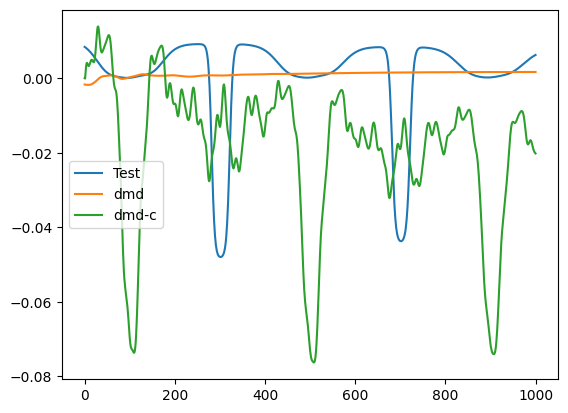

In [4]:
plt.plot(X_test[100], label='Test')
plt.plot(X_dmd_pred[100], label='dmd')
plt.plot(X_dmdc_pred[100], label='dmd-c')
plt.legend()
plt.show()


Analyzing noise level: 1%
using r: 863

Analyzing noise level: 10%
using r: 1313

Analyzing noise level: 20%
using r: 1479

Analyzing noise level: 50%
using r: 1611

Analyzing noise level: 100%
using r: 1700


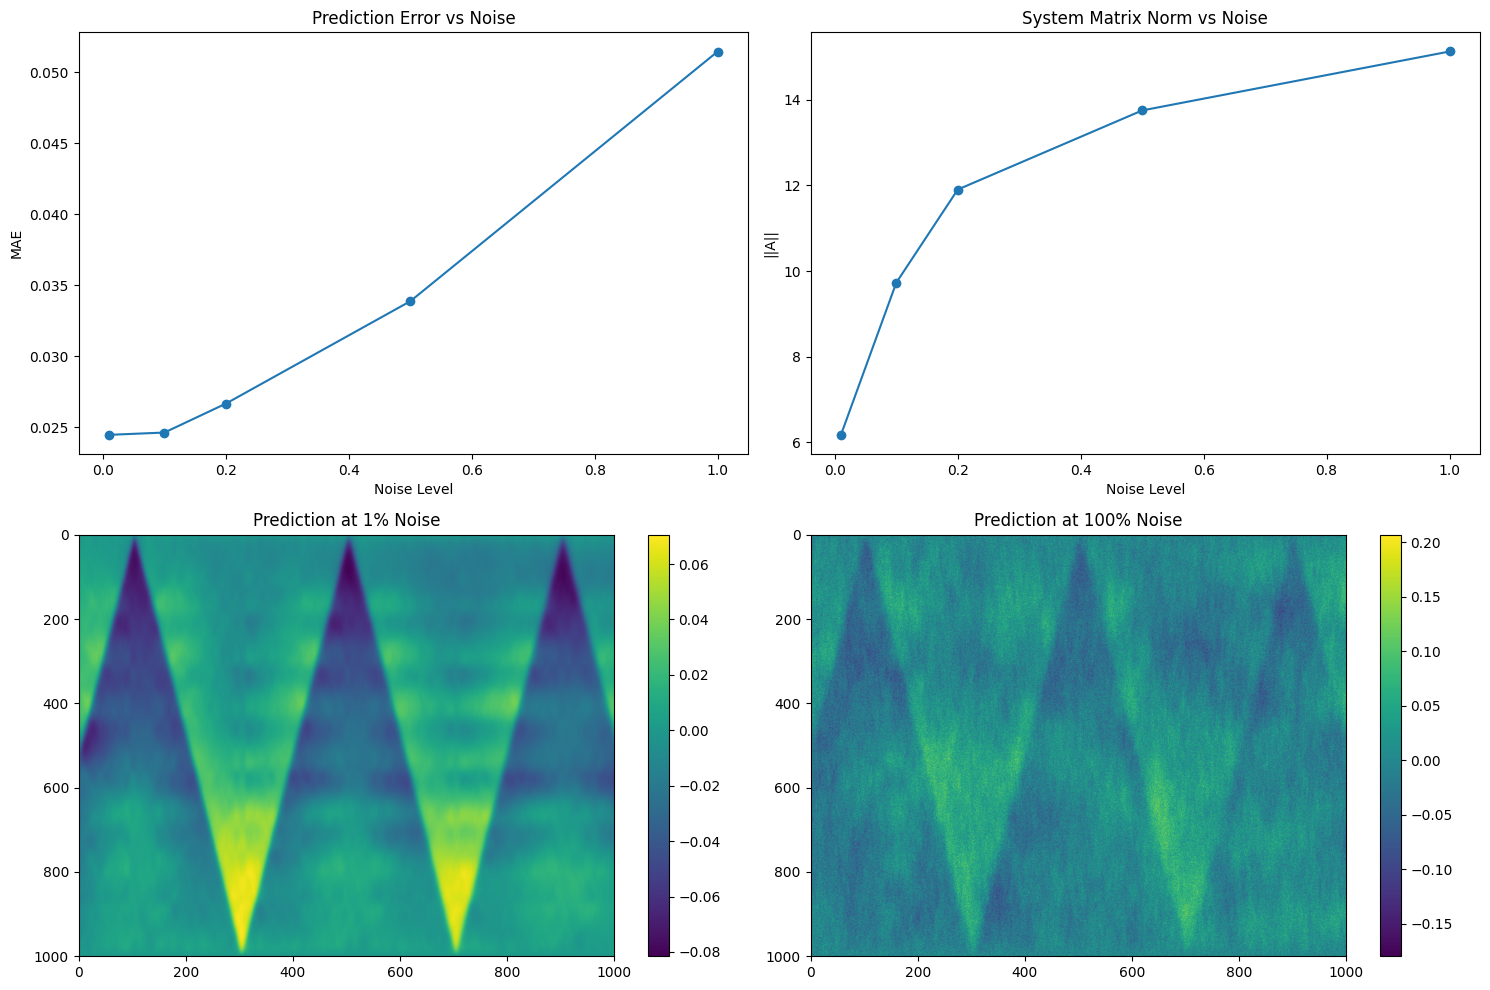


Noise Impact Summary:
Noise Level | MAE | Relative Error | ||A||
0.01 | 0.0245 | 1.8747 | 6.1749
0.10 | 0.0246 | 1.8125 | 9.7280
0.20 | 0.0267 | 1.7747 | 11.9038
0.50 | 0.0339 | 1.4627 | 13.7513
1.00 | 0.0515 | 1.2804 | 15.1278


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Modified DMDc Function with Noise Handling
# ----------------------------
def apply_dmdc(X, U, prediction_steps=50, r=None, plot_singular=False):
    """Enhanced DMDc implementation with proper scaling"""
    X1 = X[:, :-1]
    X2 = X[:, 1:]
    U1 = U[:, :X1.shape[1]]  # Ensure matching time steps

    # Reshape U for scaling (treat each spatial point as separate feature)
    U1_reshaped = U1.T  # Shape: (timesteps, spatial_points)

    # Normalize control input
    U_scaler = StandardScaler()
    U1_norm = U_scaler.fit_transform(U1_reshaped).T  # Back to original shape

    Omega = np.vstack([X1, U1_norm])

    # Truncated SVD
    U_svd, s, Vh = np.linalg.svd(Omega, full_matrices=False)
    if r is None:
        r = np.where(np.cumsum(s)/sum(s) > 0.99)[0][0] + 1
        print('using r:', r)

    Ur = U_svd[:, :r]
    Sr = np.diag(s[:r])
    Vr = Vh[:r, :]

    # Compute operators
    AB = X2 @ Vr.T @ np.linalg.inv(Sr) @ Ur.T
    A = AB[:, :X.shape[0]]
    B = AB[:, X.shape[0]:]

    # Prediction
    X_pred = np.zeros((X.shape[0], prediction_steps))
    X_pred[:, 0] = X[:, -1]  # Start from last state

    # Prepare control inputs for prediction
    U_pred = U[:, -prediction_steps:]  # Corresponding control inputs
    U_pred_reshaped = U_pred.T  # Shape: (timesteps, spatial_points)
    U_pred_norm = U_scaler.transform(U_pred_reshaped).T

    for t in range(1, prediction_steps):
        X_pred[:, t] = A @ X_pred[:, t-1] + B @ U_pred_norm[:, t-1]

    return X_pred, A, B

# ----------------------------
# Noise Analysis Framework
# ----------------------------
def analyze_noise_impact(u_clean, p_clean, noise_levels=[0.01, 0.05, 0.1, 0.2]):
    results = []

    for noise_level in noise_levels:
        print(f"\nAnalyzing noise level: {noise_level*100:.0f}%")

        # Add Gaussian noise
        u_noisy = u_clean + noise_level * np.std(u_clean) * np.random.randn(*u_clean.shape)
        p_noisy = p_clean + noise_level * np.std(p_clean) * np.random.randn(*p_clean.shape)

        # Train/test split
        split_idx = int(0.8 * u_noisy.shape[1])
        X_train = u_noisy[:, :split_idx]
        X_test = u_noisy[:, split_idx:]
        U_train = p_noisy[:, :split_idx-1]
        U_test = p_noisy[:, split_idx-1:-1]

        # Run DMDc
        X_pred, A, B = apply_dmdc(X_train, U_train,
                                 prediction_steps=X_test.shape[1])

        # Calculate metrics
        mae = mean_absolute_error(X_test.flatten(), X_pred.flatten())
        relative_err = np.linalg.norm(X_test - X_pred) / np.linalg.norm(X_test)

        results.append({
            'noise_level': noise_level,
            'mae': mae,
            'relative_error': relative_err,
            'prediction': X_pred,
            'system_matrix_norm': np.linalg.norm(A)
        })

    return results

# ----------------------------
# Visualization
# ----------------------------
def plot_noise_results(results, u_clean, p_clean):
    plt.figure(figsize=(15, 10))

    # Error vs Noise
    plt.subplot(2, 2, 1)
    plt.plot([r['noise_level'] for r in results], [r['mae'] for r in results], 'o-')
    plt.xlabel('Noise Level')
    plt.ylabel('MAE')
    plt.title('Prediction Error vs Noise')

    # System Matrix Norm
    plt.subplot(2, 2, 2)
    plt.plot([r['noise_level'] for r in results], [r['system_matrix_norm'] for r in results], 'o-')
    plt.xlabel('Noise Level')
    plt.ylabel('||A||')
    plt.title('System Matrix Norm vs Noise')

    # Sample Predictions
    for i, noise_level in enumerate([0.01, 1]):
        idx = next(j for j,r in enumerate(results) if r['noise_level'] == noise_level)

        plt.subplot(2, 2, 3+i)
        plt.imshow(results[idx]['prediction'], aspect='auto', cmap='viridis')
        plt.title(f'Prediction at {noise_level*100:.0f}% Noise')
        plt.colorbar()

    plt.tight_layout()
    plt.show()

# ----------------------------
# Main Execution
# ----------------------------
df0 = pd.read_csv('pressure.txt', delimiter="\s+", header=None)
df1 = pd.read_csv('velocity.txt', delimiter="\s+", header=None)

p_clean = df0.drop(0, axis=1).values
u_clean = df1.drop(0, axis=1).values

# Run noise analysis
noise_levels = [0.01, 0.1, 0.2, 0.5, 1]  # 1% to 20% noise
results = analyze_noise_impact(u_clean, p_clean, noise_levels)

# Visualize results
plot_noise_results(results, u_clean, p_clean)

# Print summary
print("\nNoise Impact Summary:")
print("Noise Level | MAE | Relative Error | ||A||")
for r in results:
    print(f"{r['noise_level']:.2f} | {r['mae']:.4f} | {r['relative_error']:.4f} | {r['system_matrix_norm']:.4f}")


Analyzing noise level: 0%
Using r = 49 modes for 99.9% energy

Analyzing noise level: 10%
Using r = 639 modes for 99.9% energy

Analyzing noise level: 20%
Using r = 749 modes for 99.9% energy

Analyzing noise level: 50%
Using r = 789 modes for 99.9% energy

Analyzing noise level: 100%
Using r = 795 modes for 99.9% energy


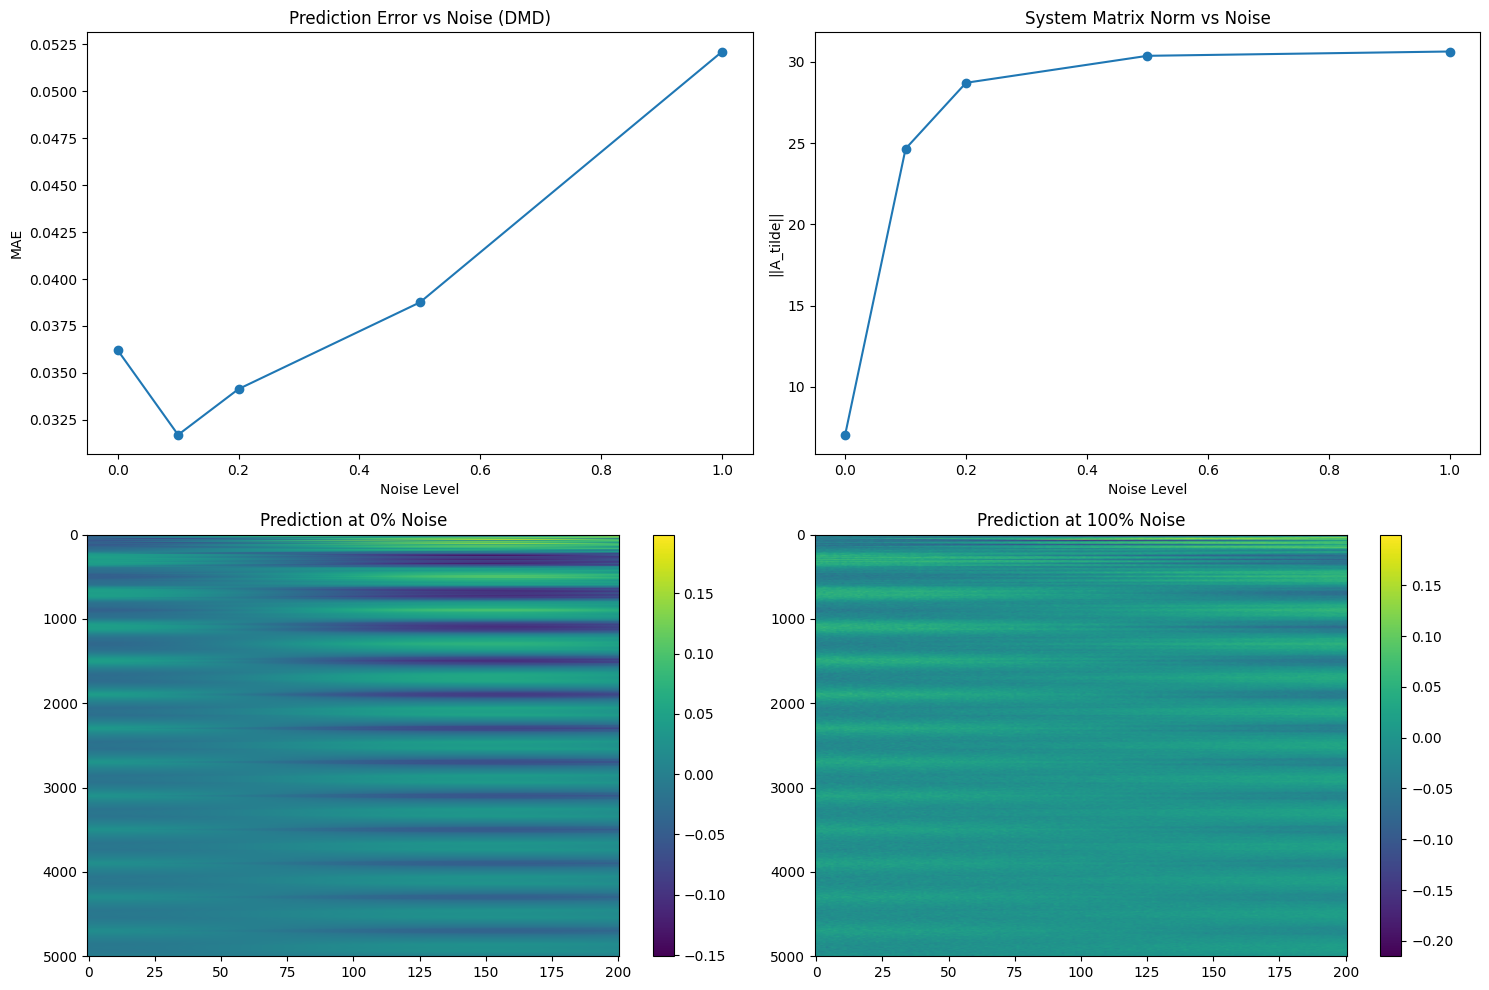


Noise Impact Summary:
Noise Level | MAE | Relative Error | ||A||
0.00 | 0.0362 | 1.2639 | 7.0368
0.10 | 0.0317 | 1.1295 | 24.6540
0.20 | 0.0341 | 1.1594 | 28.7148
0.50 | 0.0388 | 1.1546 | 30.3748
1.00 | 0.0521 | 1.1051 | 30.6405


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

# ----------------------------
# DMD Implementation (No Control)
# ----------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def apply_dmd_stable(X, prediction_steps=50, r=None, plot_singular=True):
    X1 = X[:, :-1]
    X2 = X[:, 1:]

    # Subtract mean for stability
    X_mean = np.mean(X1, axis=1, keepdims=True)
    X1 -= X_mean
    X2 -= X_mean

    # SVD
    U, S, Vh = np.linalg.svd(X1, full_matrices=False)

    # Plot singular values
    if plot_singular:
        plt.figure()
        plt.semilogy(S, 'o')
        plt.title("Singular Values of Velocity Matrix (X1)")
        plt.xlabel("Index")
        plt.ylabel("Singular Value (log scale)")
        plt.grid()
        plt.show()

    if r is None:
        energy = np.cumsum(S**2) / np.sum(S**2)
        r = np.searchsorted(energy, 0.999) + 1
        print(f"Using r = {r} modes for 99.9% energy")

    U_r = U[:, :r]
    S_r = np.diag(S[:r])
    V_r = Vh.conj().T[:, :r]

    A_tilde = U_r.T @ X2 @ V_r @ np.linalg.inv(S_r)
    eigvals, W = np.linalg.eig(A_tilde)
    Phi = X2 @ V_r @ np.linalg.inv(S_r) @ W

    # Cap unstable eigenvalues
    eigvals[np.abs(eigvals) > 1] /= np.abs(eigvals[np.abs(eigvals) > 1])

    # Initial condition
    x1 = X[:, 0:1] - X_mean
    b = np.linalg.lstsq(Phi, x1, rcond=None)[0]

    time_dynamics = np.zeros((r, prediction_steps), dtype=complex)
    for i in range(prediction_steps):
        time_dynamics[:, i] = (b.flatten() * eigvals**i)

    X_dmd = np.real(Phi @ time_dynamics) + X_mean
    return X_dmd, A_tilde

# ----------------------------
# Noise Analysis Framework
# ----------------------------
def analyze_noise_impact(u_clean, noise_levels=[0.01, 0.05, 0.1, 0.2]):
    results = []

    for noise_level in noise_levels:
        print(f"\nAnalyzing noise level: {noise_level*100:.0f}%")

        # Add Gaussian noise
        u_noisy = u_clean + noise_level * np.std(u_clean) * np.random.randn(*u_clean.shape)

        # Train/test split
        split_idx = int(0.8 * u_noisy.shape[1])
        X_train = u_noisy[:, :split_idx]
        X_test = u_noisy[:, split_idx:]

        # Run DMD
        X_pred, A_tilde = apply_dmd_stable(X_train, prediction_steps=X_test.shape[1], plot_singular=False)

        # Calculate metrics
        mae = mean_absolute_error(X_test.flatten(), X_pred.flatten())
        relative_err = np.linalg.norm(X_test - X_pred) / np.linalg.norm(X_test)

        results.append({
            'noise_level': noise_level,
            'mae': mae,
            'relative_error': relative_err,
            'prediction': X_pred,
            'system_matrix_norm': np.linalg.norm(A_tilde)
        })

    return results

# ----------------------------
# Visualization
# ----------------------------
def plot_noise_results(results, u_clean):
    plt.figure(figsize=(15, 10))

    # Error vs Noise
    plt.subplot(2, 2, 1)
    plt.plot([r['noise_level'] for r in results],
             [r['mae'] for r in results], 'o-')
    plt.xlabel('Noise Level')
    plt.ylabel('MAE')
    plt.title('Prediction Error vs Noise (DMD)')

    # System Matrix Norm
    plt.subplot(2, 2, 2)
    plt.plot([r['noise_level'] for r in results],
             [r['system_matrix_norm'] for r in results], 'o-')
    plt.xlabel('Noise Level')
    plt.ylabel('||A_tilde||')
    plt.title('System Matrix Norm vs Noise')

    # Sample Predictions
    for i, noise_level in enumerate([0, 1]):
        idx = next(j for j,r in enumerate(results) if r['noise_level'] == noise_level)

        plt.subplot(2, 2, 3+i)
        plt.imshow(results[idx]['prediction'], aspect='auto', cmap='viridis')
        plt.title(f'Prediction at {noise_level*100:.0f}% Noise')
        plt.colorbar()

    plt.tight_layout()
    plt.show()

# ----------------------------
# Main Execution
# ----------------------------
df = pd.read_csv('velocity.txt', delimiter="\s+", header=None)
u_clean = df.drop(0, axis=1).values.T  # Shape: (n_spatial, n_temporal)
# Run noise analysis
noise_levels = [0, 0.1, 0.2, 0.5, 1]  # 1% to 20% noise
results = analyze_noise_impact(u_clean, noise_levels)

# Visualize results
plot_noise_results(results, u_clean)

# Print summary
print("\nNoise Impact Summary:")
print("Noise Level | MAE | Relative Error | ||A||")
for r in results:
    print(f"{r['noise_level']:.2f} | {r['mae']:.4f} | {r['relative_error']:.4f} | {r['system_matrix_norm']:.4f}")

In [53]:
results[0]['prediction'].shape

((5001, 201), (1001, 1001))